# Feature Analysis

Before deciding which features to drop or keep, it's crucial to understand their relationships with each other and with the target variable. This notebook performs a standard exploratory feature analysis.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

# Set plot styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

## 1. Load the Data

In [14]:
DATA_DIR = Path("raw_data")
df = pd.read_csv(DATA_DIR / "Train.csv", parse_dates=["time"])

if 'target' in df.columns:
    df = df.rename(columns={'target': 'Target'})
    
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2154021, 13)


,sample_id,time,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,Target
0,20020501_-55.5_-68.5,2002-05-01,-55.5,-68.5,0.876217,-1.584223,-1.701647,-2.015145,-1.912281,-1.827801,0.5,-0.866025,0.207665
1,20020501_-55.5_-67.5,2002-05-01,-55.5,-67.5,0.998124,-1.507424,-1.569591,-2.458965,-2.172938,-2.093158,0.5,-0.866025,0.634465
2,20020501_-54.5_-71.5,2002-05-01,-54.5,-71.5,0.813429,-1.473106,-1.151013,-0.524714,-0.908085,-0.932320,0.5,-0.866025,-0.337083
3,20020501_-54.5_-70.5,2002-05-01,-54.5,-70.5,0.841872,-1.460751,-1.487956,-0.588550,-0.936815,-0.928435,0.5,-0.866025,-0.148142
4,20020501_-54.5_-69.5,2002-05-01,-54.5,-69.5,0.872800,-1.275593,-1.729794,-0.243831,-0.870009,-1.053660,0.5,-0.866025,0.089539


## 2. Missing Values Analysis

In [15]:
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
missing_percent = (missing_data / len(df)) * 100

if not missing_data.empty:
    missing_df = pd.DataFrame({'Missing Values': missing_data, 'Percentage': missing_percent})
    display(missing_df)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=missing_percent.index, y=missing_percent.values)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Percentage Missing (%)')
    plt.title('Missing Values by Feature')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found!")

No missing values found!


## 3. Correlation Analysis

Let's look at how the numerical features correlate with the `Target`. Features with high positive or negative correlation are usually very important.

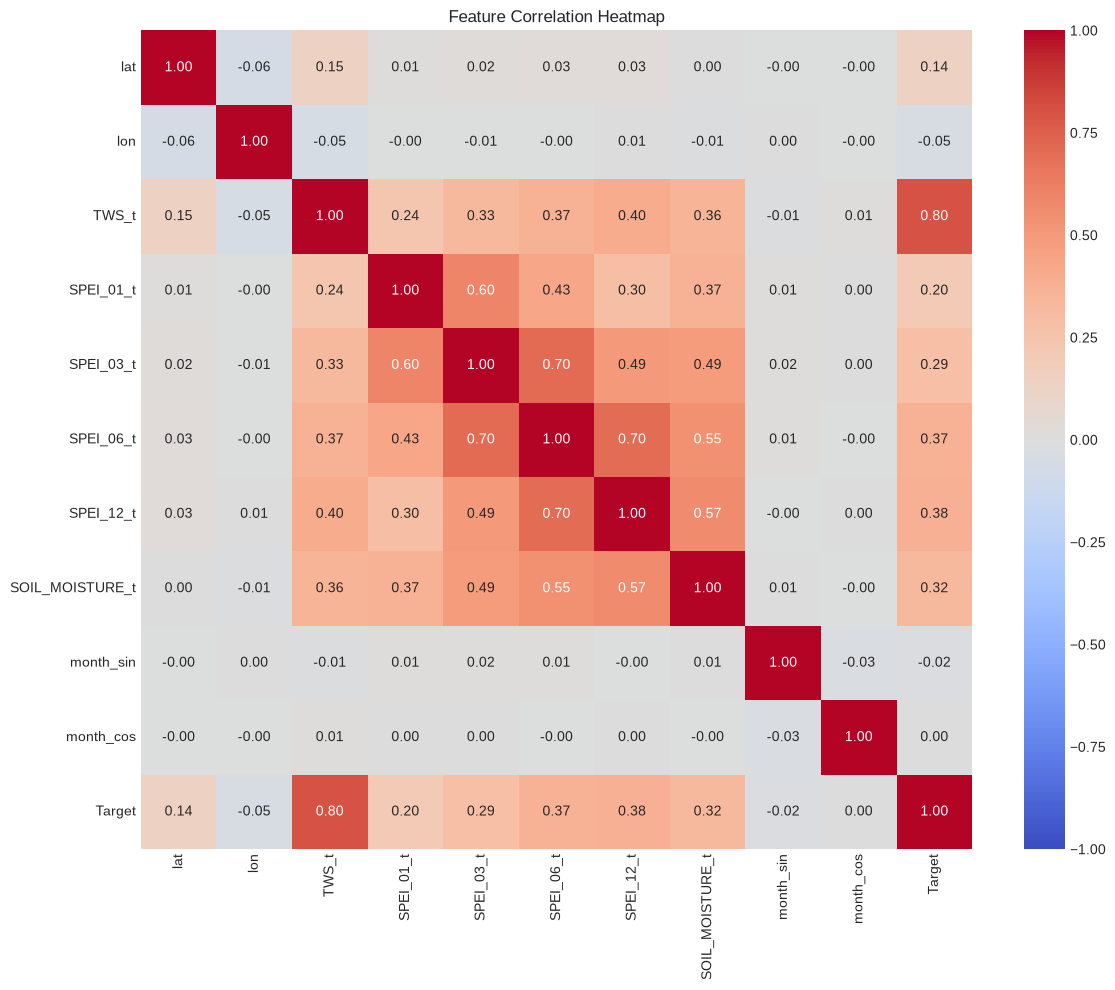

Correlation with Target:


Target             1.000000
TWS_t              0.803260
SPEI_12_t          0.379573
SPEI_06_t          0.368248
SOIL_MOISTURE_t    0.320483
SPEI_03_t          0.285371
SPEI_01_t          0.203882
lat                0.144698
month_cos          0.002764
month_sin         -0.016912
lon               -0.045923
Name: Target, dtype: float64

In [16]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

print("Correlation with Target:")
if 'Target' in corr_matrix.columns:
    target_corr = corr_matrix['Target'].sort_values(ascending=False)
    display(target_corr)

## 4. Tree-based Feature Importance (Random Forest)

Correlation only captures linear relationships. Tree-based models (like Random Forest) can capture non-linear relationships. Let's train a quick Random Forest and see which features it relies on the most.

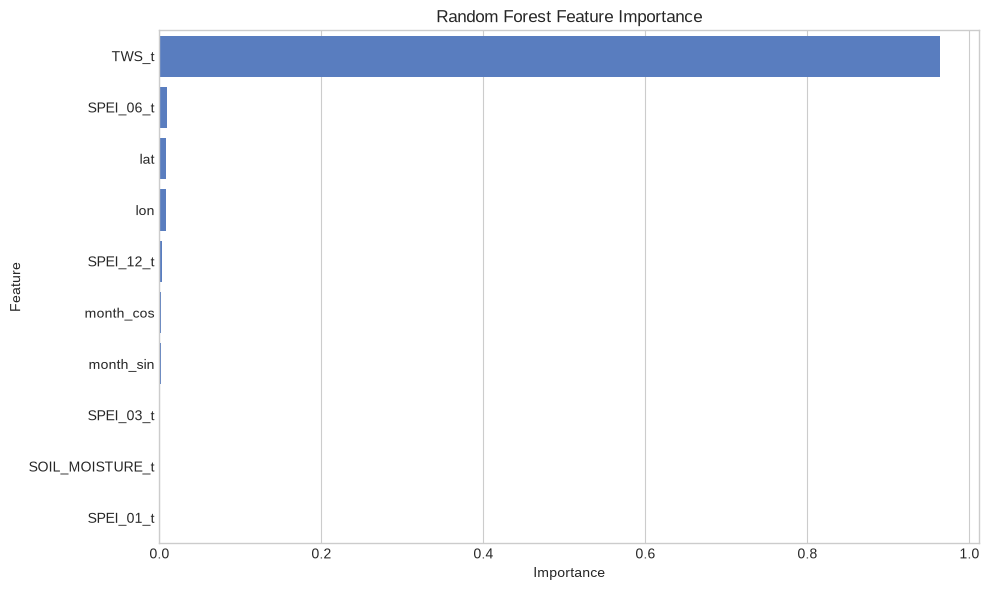

,Feature,Importance
2,TWS_t,0.963706
5,SPEI_06_t,0.009517
0,lat,0.008663
1,lon,0.008190
6,SPEI_12_t,0.003639
9,month_cos,0.001902
8,month_sin,0.001640
4,SPEI_03_t,0.001168
7,SOIL_MOISTURE_t,0.001152
3,SPEI_01_t,0.000422


In [17]:
# Drop non-numeric and ID/Target columns for the feature set
cols_to_drop = ['ID', 'sample_id', 'time', 'Target']
feature_cols = [c for c in df.columns if c not in cols_to_drop and pd.api.types.is_numeric_dtype(df[c])]

X = df[feature_cols].copy()
y = df['Target'].copy()

# Impute missing values for the Random Forest
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Train a Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_imputed, y)

# Extract and plot feature importances
importances = rf.feature_importances_
imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
imp_df = imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df, x='Importance', y='Feature')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

display(imp_df)

## 5. Principal Component Analysis (PCA)

PCA is great for **dimensionality reduction**. It helps us see if we can compress our features into fewer "components" while still retaining most of the variance (information). It's also useful for plotting the data in 2D.

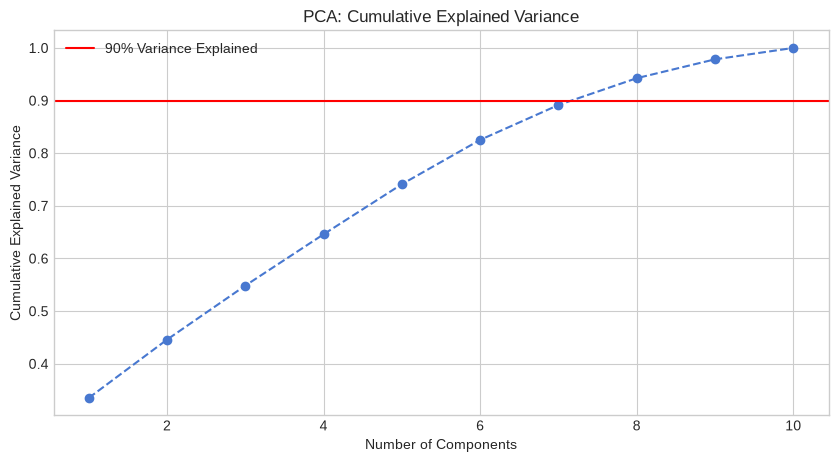

Explained variance ratio by component:
[0.33508898 0.11077021 0.10262968 0.09749757 0.09519331 0.08415309
 0.06624105 0.05096129 0.03582582 0.021639  ]


In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# PCA requires scaled data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

pca = PCA()
pca.fit(X_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('PCA: Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.90, color='r', linestyle='-', label='90% Variance Explained')
plt.legend()
plt.grid(True)
plt.show()

print("Explained variance ratio by component:")
print(explained_variance_ratio)

### Visualizing PCA in 2D
Let's see if there are any clear patterns when we squash the data down to just 2 dimensions.

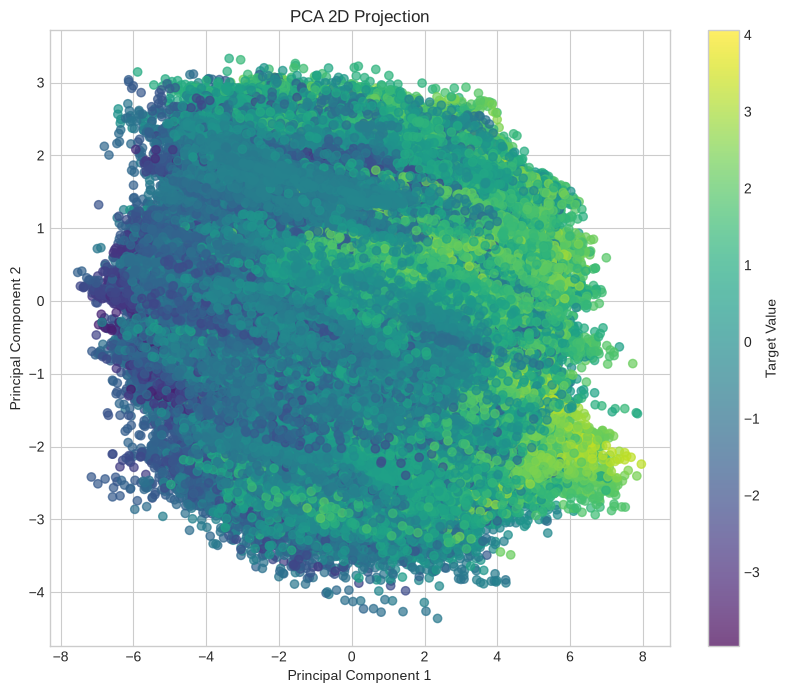


Features contributing most to Principal Component 1:


SPEI_06_t          0.471773
SPEI_03_t          0.449955
SPEI_12_t          0.431238
SOIL_MOISTURE_t    0.410387
SPEI_01_t          0.350701
TWS_t              0.310114
lat                0.035977
month_sin          0.006005
month_cos          0.002531
lon               -0.009471
dtype: float64

In [19]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
# Color points by the Target variable to see if PCA separates high/low targets
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Target Value')
plt.title('PCA 2D Projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# Let's also look at which original features make up Principal Component 1
pc1_loadings = pd.Series(pca.components_[0], index=feature_cols).sort_values(ascending=False)
print("\nFeatures contributing most to Principal Component 1:")
display(pc1_loadings)